# Python and R

This setup allows you to use *Python* and *R* in the same notebook.

To set up a similar notebook, see quickstart instructions here:

https://github.com/dmil/jupyter-quickstart

Some thoughts on why I like this setup and how I use it at the [end](notebook.ipynb#Thoughts) of  this notebook.

In [1]:
import os
os.environ["R_HOME"] = "/Library/Frameworks/R.framework/Resources"

In [2]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

In [3]:
%%javascript
// Disable auto-scrolling
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

This is a Python notebook, but below is an R cell. The `%%R` at the top of the cell indicates that the code in this cell will be R code.

In [4]:
%%R

# My commonly used R imports

require('tidyverse')

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: tidyverse


Below is a Python cell, there is nothing at the top of the cell because it is python by default.

# 👉 Read Data

In [5]:
%%R

library(ggplot2)
library(tidyr)
library(dplyr)

# Read data
df_wide <- read.csv("../data/processed/nomination_pct_wide.csv")


# 👉 Pivot to long

In [7]:
%%R

df <- df_wide %>%
  select(-Any.festival) %>%
  pivot_longer(-Year_int, names_to = "festival", values_to = "rate") %>%
  filter(!is.na(rate)) %>%
  mutate(
    festival = recode(festival,
      "CLERMONT.FERRAND" = "Clermont-Ferrand"
    )
  )

# 👉  Make ggplot chart

In [9]:
%%R

labels_df <- df %>%
  group_by(festival) %>%
  filter(Year_int == max(Year_int)) %>%
  ungroup()

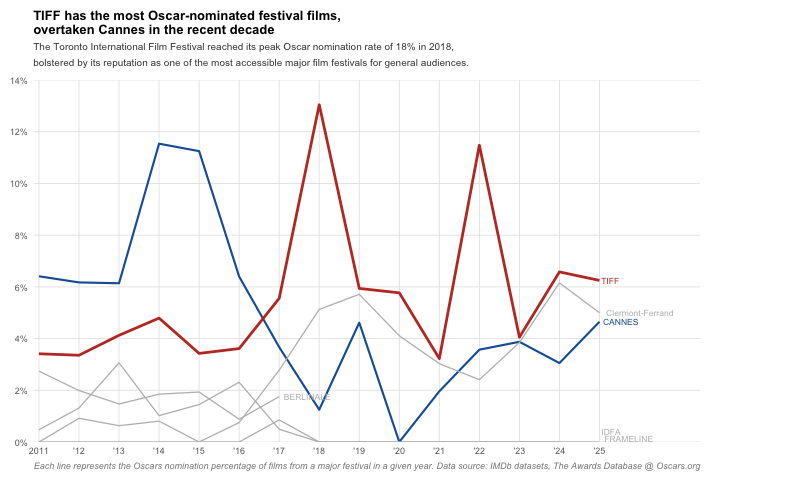

In [17]:
%%R --width=800

df <- df %>%
  mutate(
    color_group = case_when(
      festival == "TIFF"   ~ "TIFF",
      festival == "CANNES" ~ "CANNES",
      TRUE                 ~ "other"
    ),
    lw_group = case_when(
      festival == "TIFF"   ~ "TIFF",
      festival == "CANNES" ~ "CANNES",
      TRUE                 ~ "other"
    )
  )

labels_df_main <- df %>%
  group_by(festival) %>%
  filter(Year_int == max(Year_int)) %>%
  ungroup() %>%
  filter(!festival %in% c("IDFA", "FRAMELINE"))

labels_bottom <- data.frame(
  Year_int    = 2025,
  rate        = c(0.4, 0.15),
  festival    = c("IDFA", "FRAMELINE"),
  color_group = "other"
)

ggplot(df, aes(x = Year_int, y = rate, group = festival,
               color = color_group, linewidth = color_group)) +
  geom_line() +
  scale_color_manual(values = c(
    "TIFF"   = "#c0392b",
    "CANNES" = "#185FA5",
    "other"  = "#bbbbbb"
  )) +
  scale_linewidth_manual(values = c(
    "TIFF"   = 1.3,
    "CANNES" = 1.0,
    "other"  = 0.6
  )) +
  geom_text(
    data = labels_df_main,
    aes(label = festival, color = color_group),
    hjust = -0.1, size = 3, fontface = "plain"
  ) +
  geom_text(
    data = labels_bottom,
    aes(label = festival),
    hjust = -0.1, size = 3, color = "#bbbbbb", fontface = "plain"
  ) +
  scale_x_continuous(
    breaks = 2011:2025,
    labels = c("2011", paste0("'", 12:25)),
    expand = expansion(mult = c(0.01, 0.18))
  ) +
  scale_y_continuous(
    limits = c(0, 14),
    breaks = seq(0, 14, by = 2),
    labels = function(x) paste0(x, "%"),
    expand = c(0, 0)
  ) +
  labs(
    title    = "TIFF has the most Oscar-nominated festival films,\novertaken Cannes in the recent decade",
    subtitle = "The Toronto International Film Festival reached its peak Oscar nomination rate of 18% in 2018,\nbolstered by its reputation as one of the most accessible major film festivals for general audiences.",
    caption  = "Each line represents the Oscars nomination percentage of films from a major festival in a given year. Data source: IMDb datasets, The Awards Database @ Oscars.org"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position  = "none",
    plot.title       = element_text(face = "bold", size = 13),
    plot.subtitle    = element_text(size = 10, color = "#444444", lineheight = 1.4, margin = margin(b = 12)),
    panel.grid.major = element_line(color = "#e5e5e5", linewidth = 0.4),
    panel.grid.minor = element_blank(),
    axis.title       = element_blank(),
    axis.text        = element_text(color = "#666666", size = 9),
    plot.caption     = element_text(color = "#888888", face = "italic", size = 9),
    plot.margin      = margin(10, 100, 10, 10)
  )

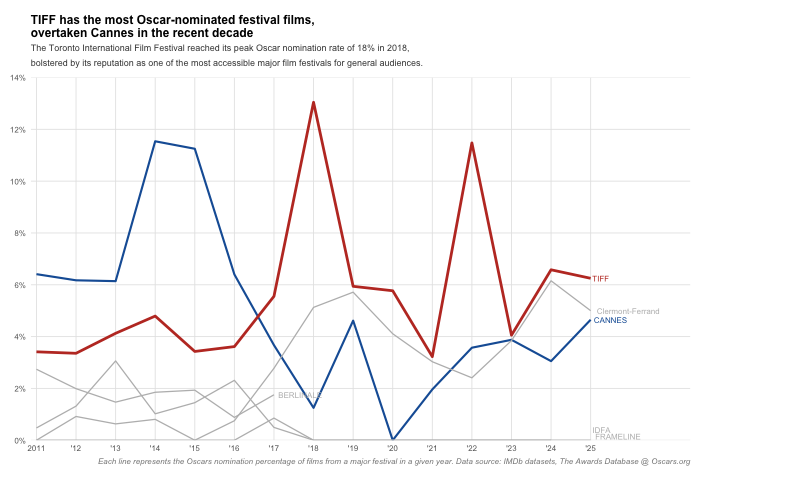

In [18]:
%%R --width=800 --height=480

df <- df %>%
  mutate(
    color_group = case_when(
      festival == "TIFF"   ~ "TIFF",
      festival == "CANNES" ~ "CANNES",
      TRUE                 ~ "other"
    ),
    lw_group = case_when(
      festival == "TIFF"   ~ "TIFF",
      festival == "CANNES" ~ "CANNES",
      TRUE                 ~ "other"
    )
  )

labels_df_main <- df %>%
  group_by(festival) %>%
  filter(Year_int == max(Year_int)) %>%
  ungroup() %>%
  filter(!festival %in% c("IDFA", "FRAMELINE"))

labels_bottom <- data.frame(
  Year_int    = 2025,
  rate        = c(0.4, 0.15),
  festival    = c("IDFA", "FRAMELINE"),
  color_group = "other"
)

ggplot(df, aes(x = Year_int, y = rate, group = festival,
               color = color_group, linewidth = color_group)) +
  geom_line() +
  scale_color_manual(values = c(
    "TIFF"   = "#c0392b",
    "CANNES" = "#185FA5",
    "other"  = "#bbbbbb"
  )) +
  scale_linewidth_manual(values = c(
    "TIFF"   = 1.3,
    "CANNES" = 1.0,
    "other"  = 0.6
  )) +
  geom_text(
    data = labels_df_main,
    aes(label = festival, color = color_group),
    hjust = -0.1, size = 2.8, fontface = "plain"
  ) +
  geom_text(
    data = labels_bottom,
    aes(label = festival),
    hjust = -0.1, size = 2.8, color = "#bbbbbb", fontface = "plain"
  ) +
  scale_x_continuous(
    breaks = 2011:2025,
    labels = c("2011", paste0("'", 12:25)),
    expand = expansion(mult = c(0.01, 0.18))
  ) +
  scale_y_continuous(
    limits = c(0, 14),
    breaks = seq(0, 14, by = 2),
    labels = function(x) paste0(x, "%"),
    expand = c(0, 0)
  ) +
  labs(
    title    = "TIFF has the most Oscar-nominated festival films,\novertaken Cannes in the recent decade",
    subtitle = "The Toronto International Film Festival reached its peak Oscar nomination rate of 18% in 2018,\nbolstered by its reputation as one of the most accessible major film festivals for general audiences.",
    caption  = "Each line represents the Oscars nomination percentage of films from a major festival in a given year. Data source: IMDb datasets, The Awards Database @ Oscars.org"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    legend.position  = "none",
    plot.title       = element_text(face = "bold", size = 12),
    plot.subtitle    = element_text(size = 9, color = "#444444", lineheight = 1.4, margin = margin(b = 10)),
    panel.grid.major = element_line(color = "#e5e5e5", linewidth = 0.4),
    panel.grid.minor = element_blank(),
    axis.title       = element_blank(),
    axis.text        = element_text(color = "#666666", size = 8),
    plot.caption     = element_text(color = "#888888", face = "italic", size = 8),
    plot.margin      = margin(10, 110, 10, 10),
    aspect.ratio     = 0.55
  )

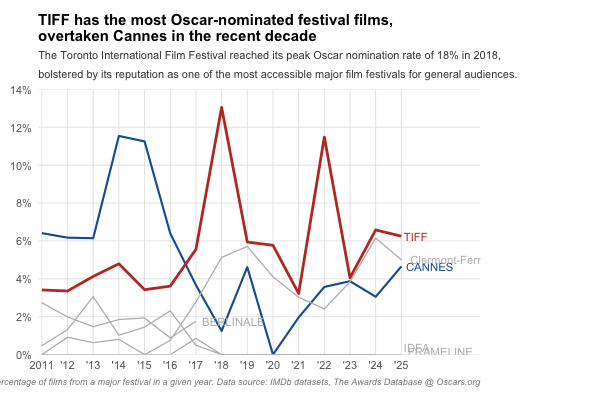

In [19]:
%%R --width=600 --height=400

ggplot(df, aes(x = Year_int, y = rate, group = festival,
               color = color_group, linewidth = color_group)) +
  geom_line() +
  scale_color_manual(values = c(
    "TIFF"   = "#c0392b",
    "CANNES" = "#185FA5",
    "other"  = "#bbbbbb"
  )) +
  scale_linewidth_manual(values = c(
    "TIFF"   = 1.3,
    "CANNES" = 1.0,
    "other"  = 0.6
  )) +
  geom_text(
    data = labels_df_main,
    aes(label = festival, color = color_group),
    hjust = -0.1, size = 4, fontface = "plain"
  ) +
  geom_text(
    data = labels_bottom,
    aes(label = festival),
    hjust = -0.1, size = 4, color = "#bbbbbb", fontface = "plain"
  ) +
  scale_x_continuous(
    breaks = 2011:2025,
    labels = c("2011", paste0("'", 12:25)),
    expand = expansion(mult = c(0.01, 0.22))
  ) +
  scale_y_continuous(
    limits = c(0, 14),
    breaks = seq(0, 14, by = 2),
    labels = function(x) paste0(x, "%"),
    expand = c(0, 0)
  ) +
  labs(
    title    = "TIFF has the most Oscar-nominated festival films,\novertaken Cannes in the recent decade",
    subtitle = "The Toronto International Film Festival reached its peak Oscar nomination rate of 18% in 2018,\nbolstered by its reputation as one of the most accessible major film festivals for general audiences.",
    caption  = "Each line represents the Oscars nomination percentage of films from a major festival in a given year. Data source: IMDb datasets, The Awards Database @ Oscars.org"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position  = "none",
    plot.title       = element_text(face = "bold", size = 15),
    plot.subtitle    = element_text(size = 11, color = "#444444", lineheight = 1.4, margin = margin(b = 10)),
    panel.grid.major = element_line(color = "#e5e5e5", linewidth = 0.4),
    panel.grid.minor = element_blank(),
    axis.title       = element_blank(),
    axis.text        = element_text(color = "#666666", size = 11),
    plot.caption     = element_text(color = "#888888", face = "italic", size = 9),
    plot.margin      = margin(10, 120, 10, 10),
    aspect.ratio     = 0.6
  )

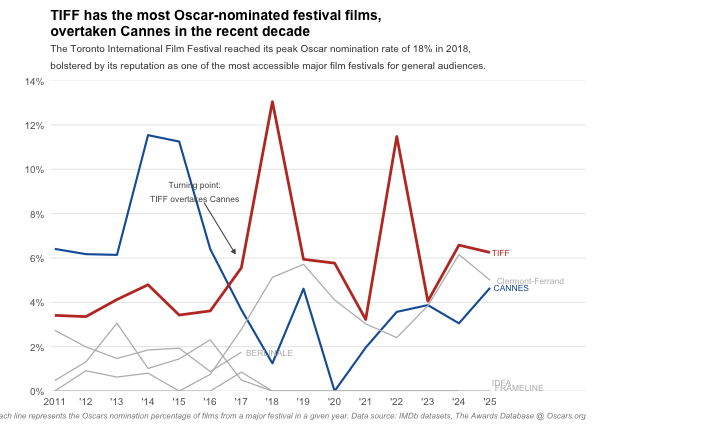

In [23]:
%%R --width=720 --height=430

ggplot(df, aes(x = Year_int, y = rate, group = festival,
               color = color_group, linewidth = color_group)) +
  geom_line() +
  scale_color_manual(values = c(
    "TIFF"   = "#c0392b",
    "CANNES" = "#185FA5",
    "other"  = "#bbbbbb"
  )) +
  scale_linewidth_manual(values = c(
    "TIFF"   = 1.3,
    "CANNES" = 1.0,
    "other"  = 0.6
  )) +
  geom_text(
    data = labels_df_main,
    aes(label = festival, color = color_group),
    hjust = -0.1, size = 3, fontface = "plain"
  ) +
  geom_text(
    data = labels_bottom,
    aes(label = festival),
    hjust = -0.1, size = 3, color = "#bbbbbb", fontface = "plain"
  ) +
  annotate(
    "segment",
    x = 2015.8, xend = 2016.8,
    y = 8.5, yend = 6.2,
    arrow = arrow(length = unit(0.15, "cm"), type = "closed"),
    color = "#555555", linewidth = 0.5
  ) +
  annotate(
    "text",
    x = 2015.5, y = 9.0,
    label = "Turning point:\nTIFF overtakes Cannes",
    hjust = 0.5, size = 3, color = "#555555", lineheight = 1.3
  ) +
  scale_x_continuous(
    breaks = 2011:2025,
    labels = c("2011", paste0("'", 12:25)),
    expand = expansion(mult = c(0.01, 0.22))
  ) +
  scale_y_continuous(
    limits = c(0, 14),
    breaks = seq(0, 14, by = 2),
    labels = function(x) paste0(x, "%"),
    expand = c(0, 0)
  ) +
  labs(
    title    = "TIFF has the most Oscar-nominated festival films,\novertaken Cannes in the recent decade",
    subtitle = "The Toronto International Film Festival reached its peak Oscar nomination rate of 18% in 2018,\nbolstered by its reputation as one of the most accessible major film festivals for general audiences.",
    caption  = "Each line represents the Oscars nomination percentage of films from a major festival in a given year. Data source: IMDb datasets, The Awards Database @ Oscars.org"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    legend.position    = "none",
    plot.title         = element_text(face = "bold", size = 14),
    plot.subtitle      = element_text(size = 10, color = "#444444", lineheight = 1.4, margin = margin(b = 10)),
    panel.grid.major   = element_line(color = "#e5e5e5", linewidth = 0.4),
    panel.grid.major.x = element_blank(),
    panel.grid.minor   = element_blank(),
    axis.title         = element_blank(),
    axis.text          = element_text(color = "#666666", size = 10),
    plot.caption       = element_text(color = "#888888", face = "italic", size = 8),
    plot.margin        = margin(10, 120, 10, 10),
    aspect.ratio       = 0.58
  )

In [25]:
%%R

install.packages("svglite")

ggsave(
  filename = "../output/tiff_chart.svg",
  plot     = last_plot(),
  width    = 10,
  height   = 6,
  units    = "in",
  device   = svglite::svglite
)

--- Please select a CRAN mirror for use in this session ---
Secure CRAN mirrors 

 1: 0-Cloud [https]                   2: Australia (Canberra) [https]   
 3: Australia (Melbourne 1) [https]   4: Australia (Melbourne 2) [https]
 5: Austria (Wien) [https]            6: Belgium (Brussels) [https]     
 7: Brazil (PR) [https]               8: Brazil (SP 1) [https]          
 9: Brazil (SP 2) [https]            10: Bulgaria [https]               
11: Canada (MB) [https]              12: Canada (ON 1) [https]          
13: Canada (ON 2) [https]            14: Chile (Santiago) [https]       
15: China (Beijing 1) [https]        16: China (Beijing 2) [https]      
17: China (Beijing 3) [https]        18: China (Hefei) [https]          
19: China (Hong Kong) [https]        20: China (Jinan) [https]          
21: China (Lanzhou) [https]          22: China (Nanjing) [https]        
23: China (Shanghai 2) [https]       24: China (Shenzhen) [https]       
25: China (Wuhan) [https]            26: C

trying URL 'https://cloud.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/svglite_2.2.2.tgz'
Content type 'application/x-gzip' length 989923 bytes (966 KB)
downloaded 966 KB

